# Étude du robot PUMA

*Par Erwan Maugeri, Charles-Antoine Maisonneuve*

- modèle géométrique / cinématique direct / inverse
    - Fixer les géométries du problème (longeur de bras, amplitude de pivot)
    - Déterminer l’ensemble des solutions (ici boule discontinue) “Workspace”
    - Associer position = tel mouvements (probablement plusieurs positions)
    - Dessiner les hodographe pour chaque commande (entrée : position, sortie : tracé de la trajectoire idéalement de chaque composante
- modèle dynamique/cinétique
    - ajouter la masse (permet de passer aux étapes suivantes)
    - bilan des efforts
- commande


## Fixer les dimensions du problème

mettre biblio \
terminer explications \
ajouter plan de route et décomposition du projet

Anatomie du PUMA:
- 2 parties: bras et tête
- que des lisaisons pivots
- 3 liaisons par partie (donc 6 au total)

<img src="anatomie_PUMA.png" height="300">

On note $R_0$ le socle puis $S_1, S_2, S_3$ les 3 parties du bras et la tête, que l'on étudiera pas tout de suite, et qu'on appelera parfois "outil".

<img src="schema_chaine_PUMA.png" height="300">

On définit ensuite les vecteurs $X_i \ Y_i \ Z_i$ de la base $R_i$ et les $q_i$ tel que
- $q _1 = (X_0, X_1)$
- $q _2 = (X_1, X_2)$
- $q _3 = (X_2, X_3)$

<img src="schema_PUMA.jpg" height="300">

On pose $L_0, L_1, L_2, L_3$ pour les longeurs de chaque bras

<img src="tailles.png" height="300">

## Étude du bras

In [328]:
import numpy as np
import matplotlib.pyplot as plt

In [329]:
## intervalle de mouvement des q, q_i ∈ I = [q_min, q_max] (trouvés sur vlabs.ac simulateur de Puma en ligne)
I_q1 = (-160, 160)
I_q2 = (-225, 45)
I_q3 = (-225, 45)

## Taille bras (proportionnelles)
H = 26.5
F = 9
G = 17
L = 17 # distance pivot-centre outil

### Quelques tests de graphes 3D (à ne pas inclure dans le rapport)

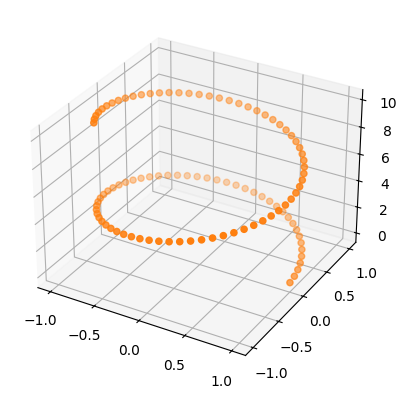

In [330]:
# test d'une fonction paramétrique vu en cours

# Syntaxe des graphe 3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# ---


t = np.linspace(0,10,100)

x = np.cos(t)
y = np.sin(t)
z = t

ax.scatter(x, y, z, color="C1")

plt.show()

(array([[1, 2, 3],
       [1, 2, 3]]), array([[10, 10, 10],
       [20, 20, 20]]))
[[1 2 3]
 [1 2 3]]
[[10 10 10]
 [20 20 20]]
[[11 12 13]
 [21 22 23]]


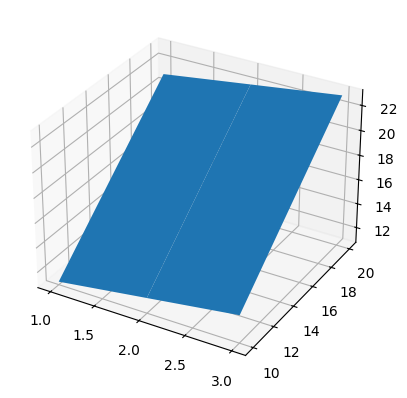

In [331]:
# test meshgrid et plot_surface

x = np.array([1, 2, 3])
y = np.array([10, 20])

# mesgrid : couples (x,y) sous la forme de tableau (voir/tester syntaxe juste en dessous)

X = np.meshgrid(x, y)
# 2 tableaux 2*3 :
#
# ([x1,x2,x3], 
#  [x1,x2,x3])
#
# ([y1,y1,y1], 
#  [y2,y2,y2])

Y = np.meshgrid(y, x)
# 2 tableaux 3*2
#
# ([y1,y2], 
#  [y1,y2],
#  [y1,y2]) 
#
# ([x1,x1], 
#  [x2,x2],
#  [x3,x3])

print(X)

# L'une ou l'autre méthode n'a pas d'incidence sur Z(X,Y) MAIS il faut le même format entre X et Y

X,Y = np.meshgrid(x, y) # syntaxe associant directement les 2 matrices de combinaisons
# voir plutot: ligne à ligne (d'une matrice à l'autre) on a tous nos couples (x,y)
print(X)
print(Y)

Z = X + Y
print(Z)

# tracé de la surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z)

plt.show()

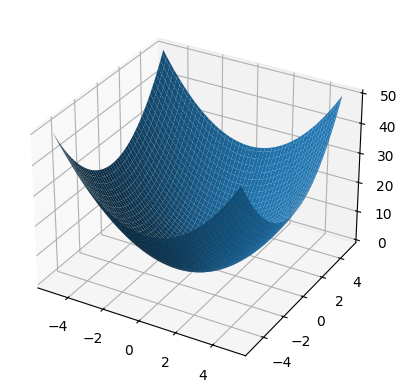

In [332]:
# tests d'affichage de surfaces (paraboloïde)

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y)  # Crée tous les couples (x,y) possibles

Z = X**2 + Y**2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z) # Associe pour un z les couples (x,y)

plt.show()

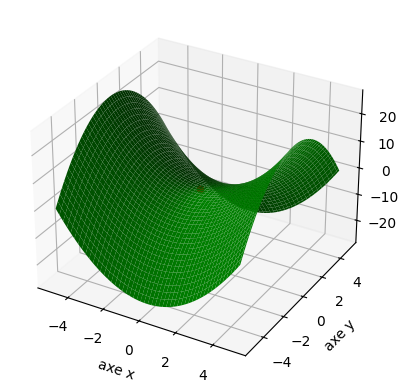

In [333]:
# tests d'affichage de surfaces (point col)

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y)  # Créer tous les couples (x,y) possibles

Z = X**2 - Y**2 # on def la fct z: (x,y) -> x^2 - y^2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, color="green")

# cherchons le point col
# dz/dx = 2*x = 0 si x = 0
# dz/dx = -2*y = 0 si y = 0
# donc (0,0, z=0^2-0^2=0) est le point col

ax.scatter(0,0,0, color='red')

# détails
ax.set_xlabel('axe x')
ax.set_ylabel('axe y')
ax.set_zlabel('axe z') # marche pas dans les fichiers notebook

plt.show()

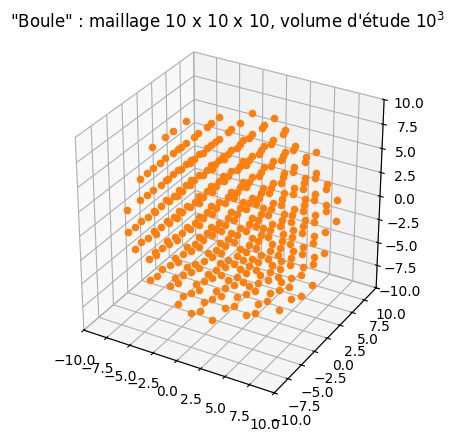

In [334]:
# tracé d'une boule (pour le workspace) [triple itération, lent]

# paramètres
R = 10
Nx, Ny, Nz = 10, 10, 10 # maillage Nx * Ny * Nz

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

X = np.linspace(-R,R,Nx)
Y = np.linspace(-R,R,Ny)
Z = np.linspace(-R,R,Nz)

for x in X:
    for y in Y:
        for z in Z:
            if x**2 + y**2 + z**2 <= R**2:
                ax.scatter(x,y,z, color="C1")

ax.set_title(f"\"Boule\" : maillage {Nx} x {Ny} x {Nz}, volume d'étude {R}$^3$")

ax.set_xlim(-R,R)
ax.set_ylim(-R,R)
ax.set_zlim(-R,R)

ax.set_aspect('equal')
plt.show()

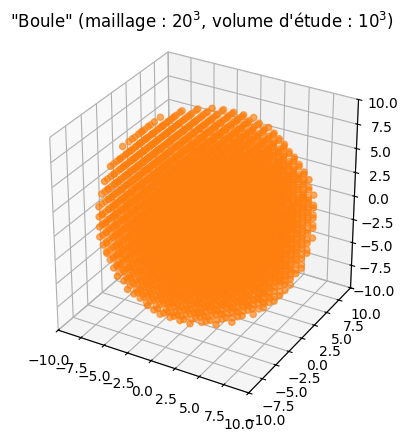

In [335]:
# tracé d'une boule (pour le workspace) [avec meshgrid, rapide]

# paramètres
R = 10
N = 20 # maillage N**3 (résolution)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

t = np.linspace(-R,R,N)
X, Y, Z = np.meshgrid(t, t, t)

mask = ( X**2 + Y**2 + Z**2 <= R**2 ) # soit True soit False => 1 , 0
# print(mask)

ax.scatter(X[mask], Y[mask], Z[mask], color="C1")

ax.set_title(f"\"Boule\" (maillage : {N}$^3$, volume d'étude : {R}$^3$)")

ax.set_xlim(-R,R)
ax.set_ylim(-R,R)
ax.set_zlim(-R,R)

ax.set_aspect('equal')
plt.show()

### Géométrie inverse

#### modèle simple en 2D: 2 bras de longeur L1 et L2

Initialisation

In [464]:
# position cible
x = 3
y = 3

# Paramètres
L1 = 3
L2 = 3

# Limites articulaires
I_q1 = (-3*np.pi/4, 3*np.pi/4)
I_q2 = (-np.pi, np.pi)

In [337]:
# modèles de géométrie inverse
def q1(x,y) :
    return np.arctan(y/x) - np.arccos( (L1**2 - L1**2 + x**2+ y**2) / (2*L1*np.sqrt(x**2 + y**2)) )

def q2(x,y) :
    return np.pi - np.arccos( (L1**2 + L2**2 - x**2 - y**2) / (2*L1*L2) )

Workspace et quelques tests

In [338]:
def q(x,y):
    ''' Fonction qui prend une position x,y et renvoie les angles [q1,q2] ou "pas de solution" si le système ne peux pas atteindre (x,y) '''
    r = np.sqrt(x**2 + y**2)
    if abs(L1-L2) <= r <= L1+L2:
        q_1 = q1(x,y)
        q_2 = q2(x,y)
        if I_q1[0] <= q_1 <= I_q1[1] and I_q2[0] <= q_2 <= I_q2[1]:
            return [float(q_1), float(q_2)]
    else:
        print("pas de solution")
        return False

In [339]:
x,y = 4,0
q(x,y)

[-0.8410686705679303, 1.318116071652818]

ici on essaye de tracer le workspace mais on a plusieurs problèmes:
1. les fonctions qu'on utilise ne sont pas vectorisées donc on peut pas utiliser la méthode de "mask" qu'on a vu précédement
2. on divise parfois par 0 dans la fonction arctan

/var/folders/mt/fccg4c5d5zs03twxg91fh66h0000gn/T/ipykernel_74915/3833103936.py:3: RuntimeWarning: invalid value encountered in arccos
  return np.arctan(y/x) - np.arccos( (L1**2 - L1**2 + x**2+ y**2) / (2*L1*np.sqrt(x**2 + y**2)) )
/var/folders/mt/fccg4c5d5zs03twxg91fh66h0000gn/T/ipykernel_74915/3833103936.py:6: RuntimeWarning: invalid value encountered in arccos
  return np.pi - np.arccos( (L1**2 + L2**2 - x**2 - y**2) / (2*L1*L2) )


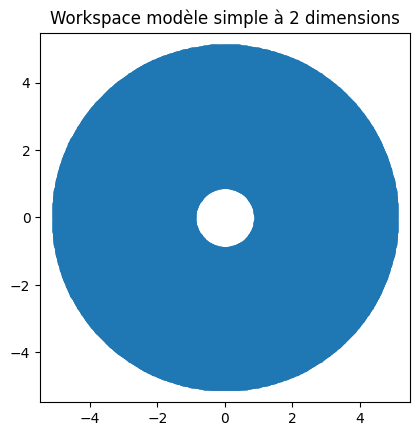

In [340]:
# Workspace
# si |L1 - L2| ≤ r ≤ L1 + L2
# et si q1 ∈ I1 , q2 ∈ I2
# donc une portion de donut

N = 500
x = np.linspace(-(L1+L2), L1+L2, N)
y = np.linspace(-(L1+L2), L1+L2, N)

X,Y = np.meshgrid(x,y)
R = np.sqrt(X**2 + Y**2)

# c'est là que ma cinématique inverse intervient
Q1 = q1(X, Y)
Q2 = q2(X, Y)

mask = (np.abs(L1-L2) <= R) & (R <= L1+L2)

fig, ax = plt.subplots()

ax.scatter(X[mask], Y[mask])

ax.set_aspect('equal')
ax.set_title('Workspace modèle simple à 2 dimensions')
plt.show()

Donc j'ai demandé à chatGPT de perfectionner mes fonctions

In [341]:
# modèles de géométrie inverse (vectorisés)

def q1(x, y):
    r = np.sqrt(x**2 + y**2)
    with np.errstate(divide='ignore', invalid='ignore'):
        angle = np.arctan2(y, x) - np.arccos((L1**2 - L2**2 + x**2 + y**2) / (2 * L1 * r))
    return angle

def q2(x, y):
    r_squared = x**2 + y**2
    with np.errstate(divide='ignore', invalid='ignore'):
        angle = np.pi - np.arccos((L1**2 + L2**2 - r_squared) / (2 * L1 * L2))
    return angle

In [342]:
# Filtrage des positions
def q(x, y):
    '''Retourne un masque booléen des points (x,y) atteignables et dans les limites articulaires.'''
    r = np.sqrt(x**2 + y**2)
    reachable = (np.abs(L1 - L2) <= r) & (r <= L1 + L2)
    q1_vals = q1(x, y)
    q2_vals = q2(x, y)
    q1_valid = (I_q1[0] <= q1_vals) & (q1_vals <= I_q1[1])
    q2_valid = (I_q2[0] <= q2_vals) & (q2_vals <= I_q2[1])
    return reachable & q1_valid & q2_valid

In [343]:
# petit test
x,y = 4,0

if q(x,y) == True :
    print(q1(x,y),q2(x,y))
else : print("pas de solution")

-0.5053605102841573 1.318116071652818


Workspace modèle simple 
 L1, L2 = (3,3) 
 ($q_1$ , $q_2$) ∈ [-2.36 ; 2.36] x [-3.14 ; 3.14]


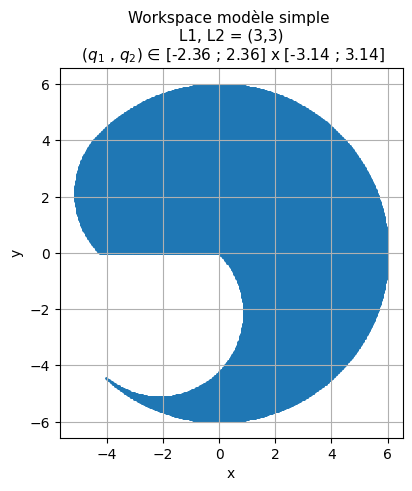

In [467]:
# dessiner le workspace

N = 500
x = np.linspace(-(L1 + L2), L1 + L2, N)
y = np.linspace(-(L1 + L2), L1 + L2, N)
X, Y = np.meshgrid(x, y)

mask = q(X, Y)

fig, ax = plt.subplots()
ax.scatter(X[mask], Y[mask], s=1)

ax.set_aspect('equal')
plt.grid(True)

ax.set_title(f'Workspace modèle simple \n L1, L2 = ({L1},{L2}) \n ($q_1$ , $q_2$) ∈ [{I_q1[0]:.2f} ; {I_q1[1]:.2f}] x [{I_q2[0]:.2f} ; {I_q2[1]:.2f}]' , size='11')
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.show()

\* Note pour la config $L_1, L_2$ = (3,3) et ($q_1$ , $q_2$) ∈ [-2.36 ; 2.36] x [-3.14 ; 3.14] : <br>
Il manque quand même le contour lorsque $q_1 = - \pi$ et qu'on fait tourner $L_2$ autour de son pivot. Ci-dessous ce à quoi ça devrait ressembler. Mais bon ... c'est déjà une très bonne approximation.

<img src="workspace2d_correct.png" height="300">

### Cinématique inverse